In [7]:
import pygame
import math
import os
pygame.init()

width, height = 1200, 800
center_x = width/2
center_y = height/2

G = 1
c = 1
M0 = 40000
EH_R = 10
L = 6
dt = 0.1

TAIL_LENGTH = 300      # number of stored points
TAIL_FADE_DIST = TAIL_LENGTH + 500   # fade scale (distance ahead)

white = (255,255,255)
black = (0,0,0)
orange = (255,165,0)

WIN = pygame.display.set_mode((width,height))
pygame.display.set_caption("planet in GR - fading tail")


def M_of_r(r):
    return M0 + .1*r*M0


def rphi_to_xy(r, phi):
    x = center_x + r*math.cos(phi)
    y = center_y + r*math.sin(phi)
    return x, y


def derivatives(r, phi, vr, omega):
    M = M_of_r(r)
    Fr = -(G*M/r**2)*(1 + (3*L**2/(c**2*r**2)))

    drdt = vr
    dphidt = omega
    dvrdt = r*omega**2 + Fr
    domegadt = -2*vr*omega/r

    return drdt, dphidt, dvrdt, domegadt


def RK4(r, phi, vr, omega):

    k1 = derivatives(r, phi, vr, omega)

    k2 = derivatives(
        r + k1[0]*dt/2,
        phi + k1[1]*dt/2,
        vr + k1[2]*dt/2,
        omega + k1[3]*dt/2
    )

    k3 = derivatives(
        r + k2[0]*dt/2,
        phi + k2[1]*dt/2,
        vr + k2[2]*dt/2,
        omega + k2[3]*dt/2
    )

    k4 = derivatives(
        r + k3[0]*dt,
        phi + k3[1]*dt,
        vr + k3[2]*dt,
        omega + k3[3]*dt
    )

    dr = dt*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0])/6
    dphi = dt*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1])/6
    dvr = dt*(k1[2] + 2*k2[2] + 2*k3[2] + k4[2])/6
    domega = dt*(k1[3] + 2*k2[3] + 2*k3[3] + k4[3])/6

    return dr, dphi, dvr, domega


class Planet:
    def __init__(self, r, phi, vr, omega):
        self.r = r
        self.phi = phi
        self.vr = vr
        self.omega = omega
        self.path = []

    def update(self):
        if self.r > EH_R:
            dr, dphi, dvr, domega = RK4(self.r, self.phi, self.vr, self.omega)
            self.r += dr
            self.phi += dphi
            self.vr += dvr
            self.omega += domega

        x, y = rphi_to_xy(self.r, self.phi)
        self.path.append((x,y))

        if len(self.path) > TAIL_LENGTH:
            self.path.pop(0)

    def draw(self, win):
        x, y = rphi_to_xy(self.r, self.phi)

        # draw fading tail
        for i in range(1, len(self.path)):
            p1 = self.path[i-1]
            p2 = self.path[i]

            dx = x - p1[0]
            dy = y - p1[1]
            dist = math.sqrt(dx*dx + dy*dy)

            alpha = max(0, 255 * (1 - dist/TAIL_FADE_DIST))
            color = (int(alpha), int(alpha), int(alpha))

            pygame.draw.line(win, color, p1, p2, 2)

        pygame.draw.circle(win, orange, (int(x),int(y)), 5)


class Mass:
    def __init__(self, R):
        self.x = center_x
        self.y = center_y
        self.R = R

    def draw(self, win):
        pygame.draw.circle(win, white, (int(self.x),int(self.y)), int(self.R))


def main():
    os.makedirs("frames", exist_ok=True)
    frame_number = 0
    MAX_FRAMES = 600   # for example
    frames = []
    run = True
    clock = pygame.time.Clock()

    black_hole = Mass(EH_R)

    r0 = 200
    phi0 = 0
    vr0 = -2

    M_init = M_of_r(r0)
    omega0 = math.sqrt((G*M_init/r0**3)*(1 + (3*L**2/(c**2*r0**2))))

    planet = Planet(r0, phi0, vr0, omega0)

    while run:
        clock.tick(60)
        WIN.fill(black)

        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                run = False

        black_hole.draw(WIN)
        planet.update()
        planet.draw(WIN)
        if frame_number < MAX_FRAMES:
            pygame.image.save(WIN, f"frames/frame_{frame_number:04d}.png")
            frame_number += 1
        pygame.display.update()

    pygame.quit()
main()


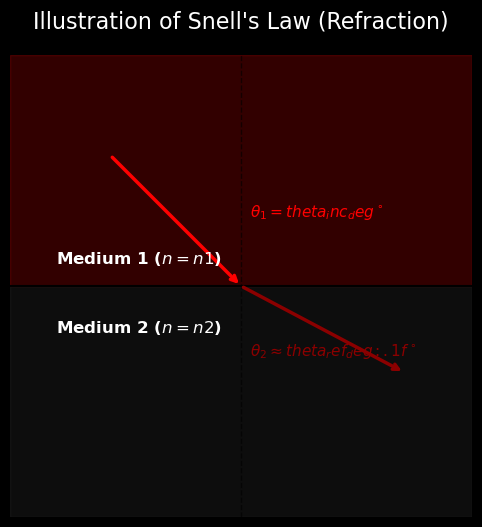

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Physics Parameters ---
n1, n2 = 1.0, .8  # Air to Water
theta_inc_deg = 45

# Calculations
theta_inc_rad = np.radians(theta_inc_deg)
theta_ref_rad = np.arcsin((n1 * np.sin(theta_inc_rad)) / n2)
theta_ref_deg = np.degrees(theta_ref_rad)

# --- 2. Setup Plot (Illustration Style) ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.axis('off')  # Hide the graph axes

# --- 3. Draw Media (Background) ---
# Upper half: Air
ax.add_patch(plt.Rectangle((-5, 0), 10, 5, color='red', alpha=0.2, label='Air ($n_1$)'))
# Lower half: Water
ax.add_patch(plt.Rectangle((-5, -5), 10, 5, color='grey', alpha=0.1, label='Water ($n_2$)'))

# Draw Interface and Normal lines
ax.axhline(0, color='black', lw=1.5)  # The boundary
ax.axvline(0, color='black', linestyle='--', lw=1, alpha=0.6)  # The normal

# --- 4. Draw Rays with Arrows ---
length = 4
# Incident ray (from top-left to center)
x1, y1 = -length * np.sin(theta_inc_rad), length * np.cos(theta_inc_rad)
ax.annotate("", xy=(0, 0), xytext=(x1, y1),
            arrowprops=dict(arrowstyle="->", color="red", lw=2.5))

# Refracted ray (from center to bottom-right)
x2, y2 = length * np.sin(theta_ref_rad), -length * np.cos(theta_ref_rad)
ax.annotate("", xy=(x2, y2), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color="darkred", lw=2.5))

# --- 5. Labels and Annotations ---
ax.text(-4, 0.5, r"Medium 1 ($n={n1}$)", fontsize=12, fontweight='bold')
ax.text(-4, -1, r"Medium 2 ($n={n2}$)", fontsize=12, fontweight='bold')

# Angle Labels
ax.text(0.2, 1.5, r"$\theta_1 = {theta_inc_deg}^\circ$", color='red', fontsize=11)
ax.text(0.2, -1.5, r"$\theta_2 \approx {theta_ref_deg:.1f}^\circ$", color='darkred', fontsize=11)

plt.title("Illustration of Snell's Law (Refraction)", fontsize=16, pad=20)
plt.show()


In [3]:
import numpy as np
import plotly.graph_objects as go

def get_refracted_ray(start_x, start_y, theta_inc_rad, n_from, n_to, length=2):
    """Calculates the end coordinates of a refracted ray."""
    # Snell's Law: n1*sin(theta1) = n2*sin(theta2)
    sin_theta_ref = (n_from * np.sin(theta_inc_rad)) / n_to
    
    # Check for Total Internal Reflection
    if abs(sin_theta_ref) > 1:
        return None, None, None
        
    theta_ref_rad = np.arcsin(sin_theta_ref)
    end_x = start_x + length * np.sin(theta_ref_rad)
    end_y = start_y - length * np.cos(theta_ref_rad)
    return end_x, end_y, theta_ref_rad

# --- 1. Setup Data ---
# Indices of refraction: Air (1.0) -> Plasma Layers (decreasing n)
indices = [1.0, 0.9, 0.7, 0.5, 0.3] 
theta_start_deg = 20
theta_start_rad = np.radians(theta_start_deg)

def create_frame_data(num_layers):
    """Generates the geometry for a specific number of plasma layers."""
    x_points = [-2 * np.sin(theta_start_rad), 0]
    y_points = [2 * np.cos(theta_start_rad), 0]
    
    curr_x, curr_y = 0, 0
    curr_angle = theta_start_rad
    
    for i in range(1, num_layers + 1):
        next_x, next_y, next_angle = get_refracted_ray(curr_x, curr_y, curr_angle, indices[i-1], indices[i])
        if next_x is None: break # Stop if TIR occurs
        x_points.append(next_x)
        y_points.append(next_y)
        curr_x, curr_y, curr_angle = next_x, next_y, next_angle
        
    return x_points, y_points

# --- 2. Build Figure ---
fig = go.Figure()

# Add Initial Ray (Air to first Plasma layer)
x_init, y_init = create_frame_data(1)
fig.add_trace(go.Scatter(x=x_init, y=y_init, mode='lines+markers', 
                         line=dict(color='orange', width=4), name="Light Path"))

# Add Frames for the Slider
frames = []
for i in range(1, len(indices)):
    xf, yf = create_frame_data(i)
    frames.append(go.Frame(data=[go.Scatter(x=xf, y=yf)], name=str(i)))
fig.frames = frames

# --- 3. Layout & Aesthetic Styling ---
fig.update_layout(
    title="Plasma Refraction: Multi-Layer Gradient (n < 1.0)",
    xaxis=dict(range=[-2, 6], visible=False),
    yaxis=dict(range=[-8, 3], visible=False),
    template="plotly_dark",
    # Add colored rectangles for plasma layers
    shapes=[
        dict(type="rect", x0=-2, y0=-2*i, x1=6, y1=-2*(i-1), 
             fillcolor="purple", opacity=0.1 * i, line_width=0, layer="below")
        for i in range(1, len(indices))
    ],
    sliders=[{
        "active": 0,
        "currentvalue": {"prefix": "Layers of Plasma: "},
        "steps": [{"args": [[f.name], {"frame": {"duration": 300, "redraw": True}, "mode": "immediate"}],
                   "label": f.name, "method": "animate"} for f in fig.frames]
    }]
)

fig.show()


In [62]:
import numpy as np
import plotly.graph_objects as go



def calculate_turning_path(num_layers, total_h=10, n_start=1.0, n_end=0.1):
    """Calculates a ray that bends from an initial angle to a horizontal path."""
    theta_init_rad = np.radians(25) # Starts at 25 degrees from the normal
    n_values = np.linspace(n_start, n_end, num_layers + 1)
    dy = total_h / num_layers
    
    # Start at the top edge (Y=5)
    x = [0]
    y = [total_h / 2]
    
    curr_x, curr_y = 0, total_h / 2
    curr_theta = theta_init_rad
    is_parallel = False

    for i in range(num_layers):
        if not is_parallel:
            # Snell's Law: n1 * sin(t1) = n2 * sin(t2)
            # Rearranged: sin(t2) = (n_in / n_out) * sin(t1)
            sin_out = (n_values[i] * np.sin(curr_theta)) / n_values[i+1]
            
            if sin_out >= 1.0:
                # Critical angle reached! Ray turns parallel.
                is_parallel = True
                # Move to the boundary where it turned
                curr_x += dy * np.tan(np.radians(85)) # Near-parallel step
                curr_y -= dy
            else:
                curr_theta = np.arcsin(sin_out)
                curr_x += dy * np.tan(curr_theta)
                curr_y -= dy
            
            x.append(curr_x)
            y.append(curr_y)
        else:
            # Ray is now parallel; keep the same Y and move to the right edge
            pass 

    # Final horizontal extension to the edge of the graph
    x.append(30)
    y.append(y[-1])
        
    return x, y

# --- 1. Prepare Plotly Steps ---
resolutions = [1, 2, 4, 8, 16, 32, 64, 128]
fig = go.Figure()

for i, res in enumerate(resolutions):
    xr, yr = calculate_turning_path(res)
    fig.add_trace(go.Scatter(
        x=xr, y=yr, mode='lines',
        line=dict(color='cyan', width=4, shape='spline' if res > 20 else 'linear'),
        visible=(i == 0)
    ))

# --- 2. Generate Gradient Blocks ---
all_shape_sets = []
for res in resolutions:
    dy = 10 / res
    shapes = []
    for j in range(res):
        shapes.append(dict(
            type="rect", x0=-2, x1=30, y0=5-(j+1)*dy, y1=5-j*dy,
            fillcolor="purple", opacity=min(0.05 + (j/res)*0.4, 0.5),
            line=dict(color="rgba(255,255,255,0.1)", width=0.5 if res < 32 else 0),
            layer="below"
        ))
    all_shape_sets.append(shapes)

# --- 3. Slider Setup ---
steps = []
for i in range(len(resolutions)):
    steps.append(dict(
        method="update", label=str(resolutions[i]),
        args=[{"visible": [j == i for j in range(len(resolutions))]},
              {"shapes": all_shape_sets[i]}]
    ))

# --- 4. Layout ---
fig.update_layout(
    title="Plasma Refraction: The Transition to Parallel (Total Reflection)",
    template="plotly_dark",
    xaxis=dict(visible=False, range=[-1, 30]),
    yaxis=dict(visible=False, range=[-5.5, 5.5]),
    sliders=[dict(active=0, steps=steps, currentvalue={"prefix": "Resolution: "}, pad={"t": 50})]
)

fig.show()

